<BarContainer object of 11 artists>

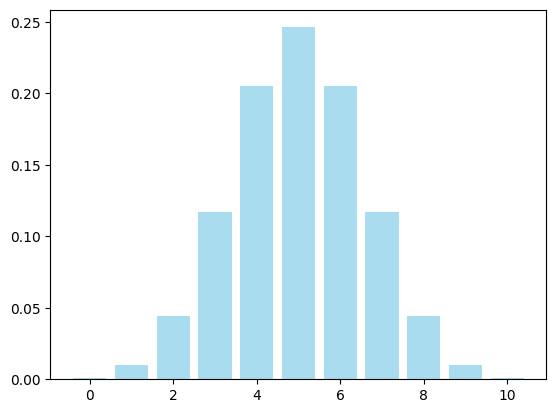

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 10  # Fixed number of trials
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]  # Different probabilities of success
x = np.arange(0, n + 1)  # Possible outcomes (0 to n)

pmf = binom.pmf(x, n, p_values[2])
plt.bar(x, pmf, color='skyblue', alpha=0.7, label=f'p = {p_values[0]}')

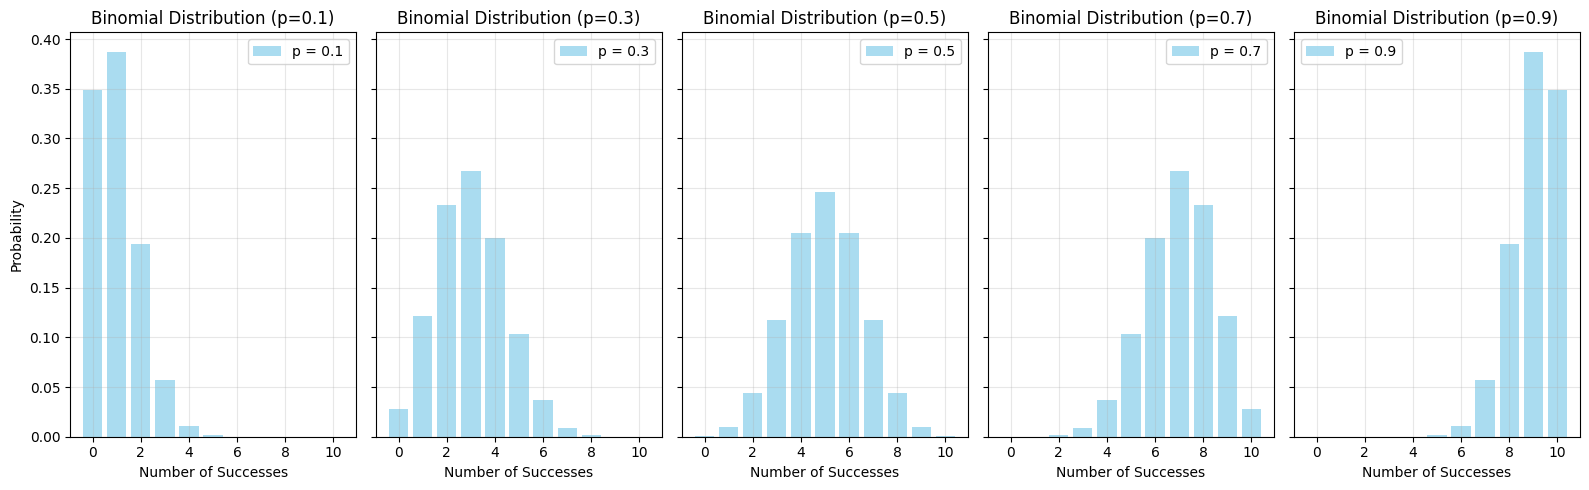

In [5]:
# Create subplots
fig, axes = plt.subplots(1, len(p_values), figsize=(16, 5), sharey=True)

for i, p in enumerate(p_values):
    # Calculate PMF for each probability of success
    pmf = binom.pmf(x, n, p)

    # Plot
    axes[i].bar(x, pmf, color='skyblue', alpha=0.7, label=f'p = {p}')
    axes[i].set_title(f'Binomial Distribution (p={p})', fontsize=12)
    axes[i].set_xlabel('Number of Successes', fontsize=10)
    axes[i].set_ylabel('Probability' if i == 0 else '', fontsize=10)
    axes[i].legend()
    axes[i].grid(alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

tips = pd.read_csv("tips.csv")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [39]:
grouped_smkoking_whole_data = pd.DataFrame(tips["smoker"].value_counts(normalize=True))
grouped_smkoking_whole_data["Total_customers"] = tips.groupby("smoker")["smoker"].count().values

In [40]:
grouped_smkoking_whole_data

,proportion,Total_customers
smoker,,
No,0.618852,151
Yes,0.381148,93


In [13]:
## What is the expected number of people who smoke..?
tips.shape[0] * 0.381148

93.000112

In [16]:
grouped_smoker_data = tips.groupby('sex')['smoker'].value_counts(normalize=True).unstack()

print(grouped_smoker_data)

smoker        No       Yes
sex                       
Female  0.620690  0.379310
Male    0.617834  0.382166


In [17]:
grouped_smoker_data['Total_Customers'] = tips.groupby('sex')['smoker'].count()

In [18]:
grouped_smoker_data

smoker,No,Yes,Total_Customers
sex,,,
Female,0.620690,0.379310,87
Male,0.617834,0.382166,157


In [19]:
## Expected number of females who smokes?

In [20]:
grouped_smoker_data["Total_Customers"].loc["Female"] * grouped_smoker_data["Yes"].loc["Female"]

33.0

In [24]:
## Expecetd number males who doesn;t smoke..?
(grouped_smoker_data["Total_Customers"].loc["Male"] * grouped_smoker_data["No"].loc["Male"])/grouped_smoker_data["Total_Customers"].loc["Male"]

0.6178343949044586

In [42]:
(tips.shape[0] * grouped_smkoking_whole_data["proportion"]["Yes"] * grouped_smkoking_whole_data["proportion"]["No"]) ** 1/2

28.776639344262293

In [31]:
#Expected value
#grouped_smoker_data['Expected_Smokers'] = grouped_smoker_data['Total_Customers'] * grouped_smoker_data['Yes']

#print(grouped_smoker_data[['Total_Customers', 'Expected_Smokers']])

In [33]:
#Standard Deviation

# import numpy as np

# # Calculate standard deviation (Variability)
# grouped_smoker_data['Std_Deviation'] = np.sqrt(
#     grouped_smoker_data['Total_Customers'] * grouped_smoker_data['Yes'] * (1 - grouped_smoker_data['Yes'])
# )

# print(grouped_smoker_data[['Total_Customers', 'Expected_Smokers', 'Std_Deviation']])

In [34]:
# from scipy.stats import binom

# # PMF for exactly 50 smokers in each gender group
# grouped_smoker_data['PMF_50_Smokers'] = grouped_smoker_data.apply(
#     lambda row: binom.pmf(50, row['Total_Customers'], row['Yes']),
#     axis=1
# )

# print(grouped_smoker_data[['Total_Customers', 'Expected_Smokers', 'PMF_50_Smokers']])

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameters
lambda_values = [2, 5, 10]  # Different average rates (lambda)
x = np.arange(0, 3)  # Possible values of events (0 to 19)
poisson.cdf(x,lambda_values[1])

array([0.00673795, 0.04042768, 0.12465202])

In [37]:
pmf = poisson.pmf(x, lambda_values[0])

<BarContainer object of 20 artists>

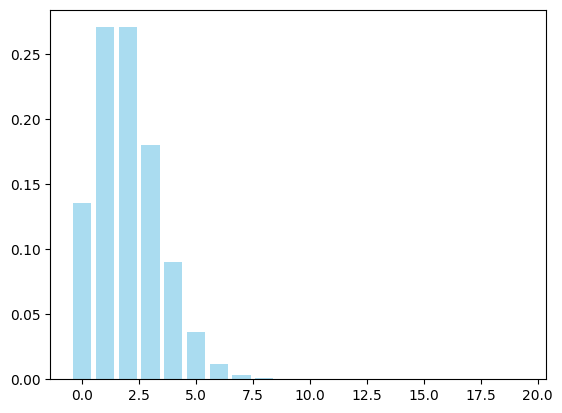

In [39]:
plt.bar(x, pmf, color='skyblue', alpha=0.7, label=f'λ = {lambda_values[0]}')

In [49]:
from scipy.stats import uniform
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [52]:
X = np.linspace(0,100,1000)
pdf = uniform.pdf(X,scale=100-0)

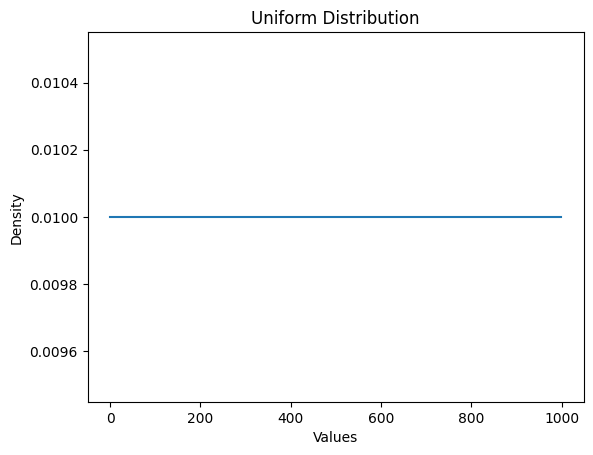

In [59]:
plt.plot(pdf,label="Uniform")
plt.title("Uniform Distribution")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

In [60]:
cdf = uniform.cdf(X,scale=100-0)

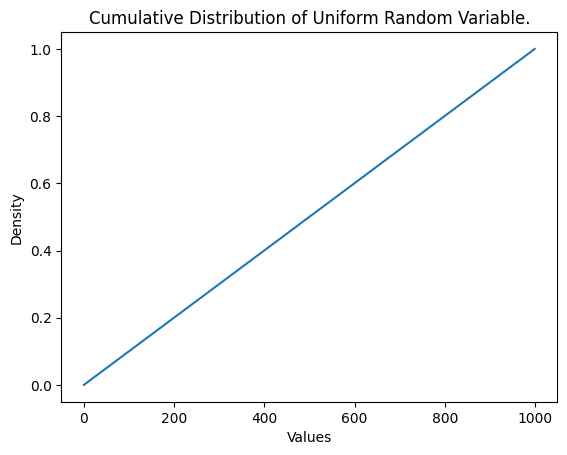

In [64]:
plt.plot(cdf)
plt.title("Cumulative Distribution of Uniform Random Variable.")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

In [66]:
from scipy.stats import expon

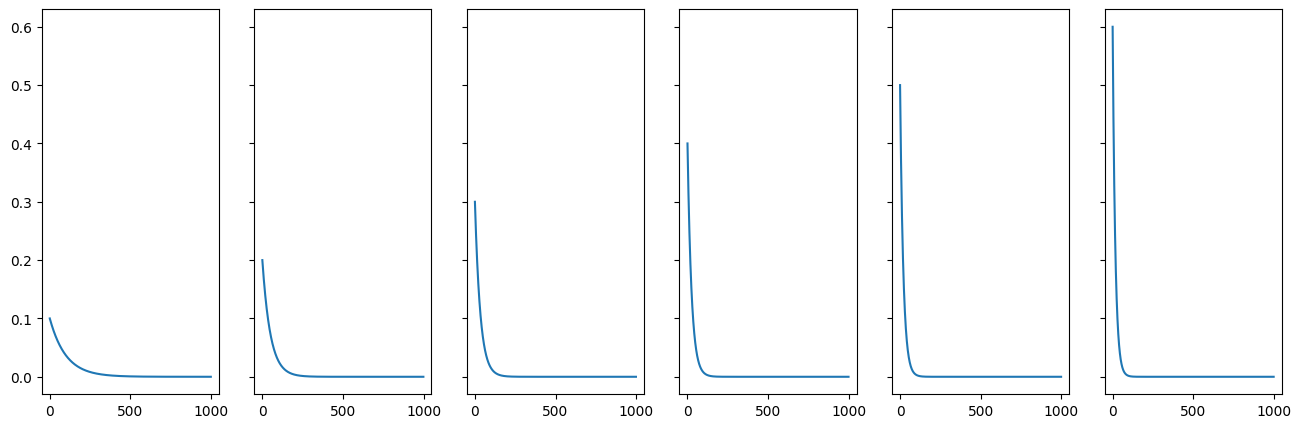

In [75]:
figure, axes = plt.subplots(1,6,figsize=(16,5),sharey=True)
i = 0
for lambda_ in [0.1,0.2,0.3,0.4,0.5,0.6]:
    pdf = expon.pdf(X,scale=1/lambda_)
    axes[i].plot(pdf)
    i += 1

Text(0, 0.5, 'Learning Rate')

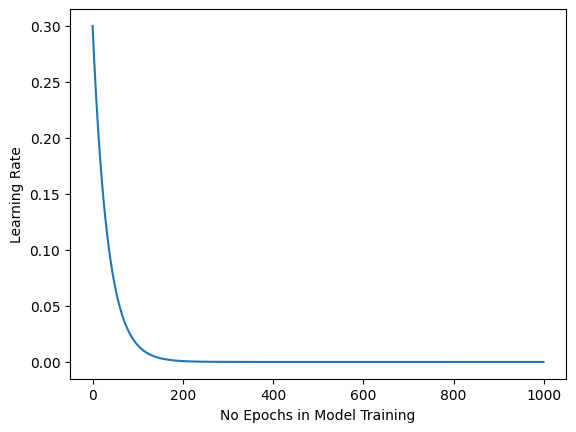

In [79]:
## If you increase the lambda value then the function decays very faster.
## Future :: Hyper Parameter Tuning. 
plt.plot(expon.pdf(X,scale=1/0.3))
plt.xlabel("No Epochs in Model Training")
plt.ylabel("Learning Rate")

In [104]:
from scipy.stats import norm

In [105]:
pdf = norm.pdf(X)

In [106]:
mean_ = X.mean()
var_ = X.std() ** 2

In [107]:
new_X = np.linspace(mean_-(4*var_), mean_+(4*var_),1000)

In [117]:
new_X

array([-3.29000667e+03, -3.28331997e+03, -3.27663327e+03, -3.26994657e+03,
       -3.26325987e+03, -3.25657317e+03, -3.24988647e+03, -3.24319977e+03,
       -3.23651307e+03, -3.22982637e+03, -3.22313967e+03, -3.21645297e+03,
       -3.20976627e+03, -3.20307957e+03, -3.19639287e+03, -3.18970617e+03,
       -3.18301947e+03, -3.17633277e+03, -3.16964607e+03, -3.16295937e+03,
       -3.15627267e+03, -3.14958597e+03, -3.14289927e+03, -3.13621257e+03,
       -3.12952587e+03, -3.12283917e+03, -3.11615247e+03, -3.10946577e+03,
       -3.10277907e+03, -3.09609237e+03, -3.08940567e+03, -3.08271897e+03,
       -3.07603227e+03, -3.06934557e+03, -3.06265887e+03, -3.05597217e+03,
       -3.04928547e+03, -3.04259877e+03, -3.03591207e+03, -3.02922537e+03,
       -3.02253867e+03, -3.01585197e+03, -3.00916527e+03, -3.00247857e+03,
       -2.99579187e+03, -2.98910517e+03, -2.98241847e+03, -2.97573177e+03,
       -2.96904507e+03, -2.96235837e+03, -2.95567167e+03, -2.94898497e+03,
       -2.94229827e+03, -

In [112]:
pdf = norm.pdf(new_X,loc = mean_, scale = var_)

In [118]:
pdf

array([1.60275399e-07, 1.65487150e-07, 1.70857417e-07, 1.76390643e-07,
       1.82091386e-07, 1.87964316e-07, 1.94014222e-07, 2.00246011e-07,
       2.06664713e-07, 2.13275483e-07, 2.20083604e-07, 2.27094488e-07,
       2.34313681e-07, 2.41746865e-07, 2.49399859e-07, 2.57278625e-07,
       2.65389268e-07, 2.73738043e-07, 2.82331353e-07, 2.91175754e-07,
       3.00277961e-07, 3.09644847e-07, 3.19283449e-07, 3.29200968e-07,
       3.39404778e-07, 3.49902422e-07, 3.60701622e-07, 3.71810278e-07,
       3.83236475e-07, 3.94988482e-07, 4.07074761e-07, 4.19503965e-07,
       4.32284947e-07, 4.45426762e-07, 4.58938666e-07, 4.72830127e-07,
       4.87110826e-07, 5.01790659e-07, 5.16879744e-07, 5.32388422e-07,
       5.48327265e-07, 5.64707077e-07, 5.81538897e-07, 5.98834008e-07,
       6.16603937e-07, 6.34860461e-07, 6.53615610e-07, 6.72881676e-07,
       6.92671209e-07, 7.12997031e-07, 7.33872232e-07, 7.55310181e-07,
       7.77324528e-07, 7.99929207e-07, 8.23138445e-07, 8.46966762e-07,
      

In [115]:
X

array([  0.        ,   0.1001001 ,   0.2002002 ,   0.3003003 ,
         0.4004004 ,   0.5005005 ,   0.6006006 ,   0.7007007 ,
         0.8008008 ,   0.9009009 ,   1.001001  ,   1.1011011 ,
         1.2012012 ,   1.3013013 ,   1.4014014 ,   1.5015015 ,
         1.6016016 ,   1.7017017 ,   1.8018018 ,   1.9019019 ,
         2.002002  ,   2.1021021 ,   2.2022022 ,   2.3023023 ,
         2.4024024 ,   2.5025025 ,   2.6026026 ,   2.7027027 ,
         2.8028028 ,   2.9029029 ,   3.003003  ,   3.1031031 ,
         3.2032032 ,   3.3033033 ,   3.4034034 ,   3.5035035 ,
         3.6036036 ,   3.7037037 ,   3.8038038 ,   3.9039039 ,
         4.004004  ,   4.1041041 ,   4.2042042 ,   4.3043043 ,
         4.4044044 ,   4.5045045 ,   4.6046046 ,   4.7047047 ,
         4.8048048 ,   4.9049049 ,   5.00500501,   5.10510511,
         5.20520521,   5.30530531,   5.40540541,   5.50550551,
         5.60560561,   5.70570571,   5.80580581,   5.90590591,
         6.00600601,   6.10610611,   6.20620621,   6.30

In [1]:
from scipy.stats import probplot
# Verify Normality Using QQ Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
probplot(tips['total_bill'], dist=norm, plot=ax[0])
probplot(total_bill_th, dist=norm, plot=ax[1])
ax[0].set_title('Total bill QQ Plot')
ax[1].set_title('Total bill THEORETICAL QQ Plot')
plt.show()

NameError: name 'plt' is not defined

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot

# Load the Tips dataset
tips = sns.load_dataset('tips')
print(tips.head())

# Mean and Std Dev of 'total_bill'
print(tips['total_bill'].mean(), tips['total_bill'].std())

# Generate a theoretical normal distribution based on mean and std dev of 'total_bill'
total_bill_th = norm.rvs(loc=tips['total_bill'].mean(), scale=tips['total_bill'].std(), size=len(tips))

# Plot Histograms, KDEs, and Boxplots for Theoretical and Actual Data
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
plt.suptitle('Theoretical total bill data')
sns.histplot(total_bill_th, ax=ax[0])
sns.kdeplot(total_bill_th, ax=ax[1])
sns.boxplot(total_bill_th, ax=ax[2])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle('Actual total bill data')
sns.histplot(data=tips, x='total_bill', ax=ax[0])
sns.kdeplot(data=tips, x='total_bill', ax=ax[1])
sns.boxplot(data=tips, y='total_bill', ax=ax[2])
plt.show()

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1002)>

In [3]:
# Calculate Mean, Median, and Standard Deviation
mean = np.mean(sepal_width)
median = np.median(sepal_width)
std_dev = np.std(sepal_width)

# Skewness and Kurtosis
data_skewness = skew(sepal_width)
data_kurtosis = kurtosis(sepal_width, fisher=False)  # Use fisher=False for Pearson's kurtosis

# Empirical Percentages
one_sd = ((sepal_width >= mean - std_dev) & (sepal_width <= mean + std_dev)).sum() / len(sepal_width) * 100
two_sd = ((sepal_width >= mean - 2 * std_dev) & (sepal_width <= mean + 2 * std_dev)).sum() / len(sepal_width) * 100
three_sd = ((sepal_width >= mean - 3 * std_dev) & (sepal_width <= mean + 3 * std_dev)).sum() / len(sepal_width) * 100

# Print Summary
print(f"Mean: {mean:.2f}, Median: {median:.2f}, Std Dev: {std_dev:.2f}")
print(f"Skewness: {data_skewness:.2f} (0 for perfect symmetry)")
print(f"Kurtosis: {data_kurtosis:.2f} (3 for normal distribution)")
print(f"Percentage within 1σ: {one_sd:.2f}% (Expected: 68%)")
print(f"Percentage within 2σ: {two_sd:.2f}% (Expected: 95%)")
print(f"Percentage within 3σ: {three_sd:.2f}% (Expected: 99.7%)")

# Histogram and Normal PDF
x = np.linspace(sepal_width.min(), sepal_width.max(), 1000)
pdf = norm.pdf(x, loc=mean, scale=std_dev)

plt.figure(figsize=(12, 6))
plt.hist(sepal_width, bins=15, density=True, alpha=0.6, color='skyblue', label="Histogram")
plt.plot(x, pdf, label="Fitted Normal PDF", color='red')
plt.title("Sepal Width Distribution and Normal Fit", fontsize=16)
plt.xlabel("Sepal Width (cm)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.axvline(mean, color='blue', linestyle='--', label=f"Mean: {mean:.2f}")
plt.axvline(median, color='green', linestyle='--', label=f"Median: {median:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Standard Deviation Coverage
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label="PDF", color='blue')
plt.axvspan(mean - std_dev, mean + std_dev, color='yellow', alpha=0.3, label="1σ (68%)")
plt.axvspan(mean - 2 * std_dev, mean + 2 * std_dev, color='orange', alpha=0.3, label="2σ (95%)")
plt.axvspan(mean - 3 * std_dev, mean + 3 * std_dev, color='pink', alpha=0.3, label="3σ (99.7%)")
plt.title("Standard Deviations Coverage in Sepal Width", fontsize=16)
plt.xlabel("Sepal Width (cm)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NameError: name 'np' is not defined

In [8]:
import pandas as pd
import numpy as np
tips = pd.read_csv("tips.csv")

In [6]:
mean_ =  tips["total_bill"].mean()
variance = tips["total_bill"].var()

In [16]:
x = np.linspace(mean_ - 4*variance,mean_ + 4*variance, 1000)

In [17]:
from scipy.stats import norm

In [18]:
pdf = norm.pdf(x,loc=mean_,scale=variance)

In [19]:
from matplotlib import pyplot as plt

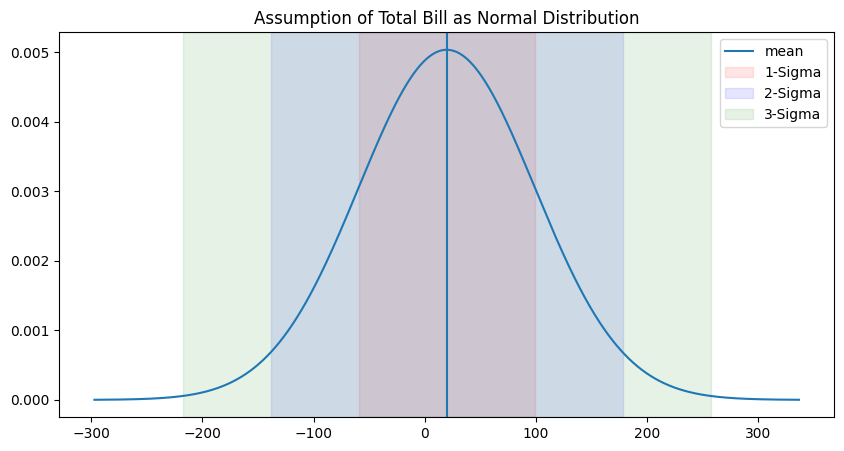

In [34]:
plt.figure(figsize=(10,5))
plt.plot(x,pdf)
plt.axvline(mean_,label="mean")
plt.axvspan(mean_-variance,mean_ + variance, color="red",alpha = 0.1, label="1-Sigma")
plt.axvspan(mean_-2*variance, mean_+2*variance, color="blue",alpha = 0.1, label="2-Sigma")
plt.axvspan(mean_-3*variance, mean_+3*variance, color="green",alpha = 0.1, label="3-Sigma")
plt.title("Assumption of Total Bill as Normal Distribution")
plt.legend()

In [35]:
tips["total_bill"]

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

In [36]:
from scipy.stats import probplot

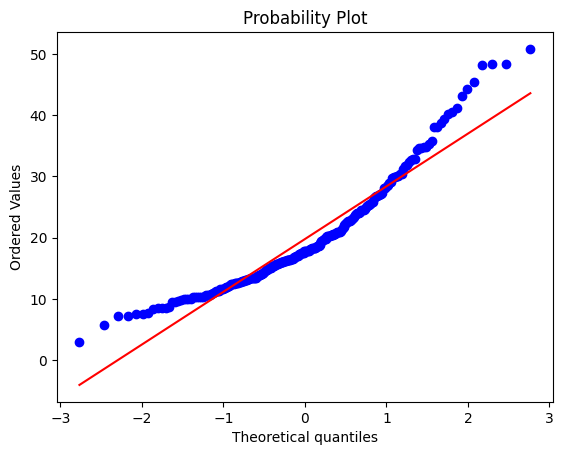

In [42]:
ax = plt.subplot(1,1,1)
probplot(tips["total_bill"],dist="norm",plot=ax);

In [47]:
theoretical_samples = norm.rvs(loc=mean_,scale=variance,size=244)
# theoretical_probs = norm.pdf(theoretical_samples,loc=mean_,scale=variance)

In [51]:
total_bills = tips["total_bill"]
# total_bills_probs = norm.pdf()

In [56]:
import seaborn as sns
sns.histogram(theoretical_samples)
sns.kde(theoretical_samples)

AttributeError: module 'seaborn' has no attribute 'histogram'

(array([ 7., 42., 68., 51., 31., 19., 12.,  7.,  3.,  4.]),
 array([ 3.07 ,  7.844, 12.618, 17.392, 22.166, 26.94 , 31.714, 36.488,
        41.262, 46.036, 50.81 ]),
 <BarContainer object of 10 artists>)

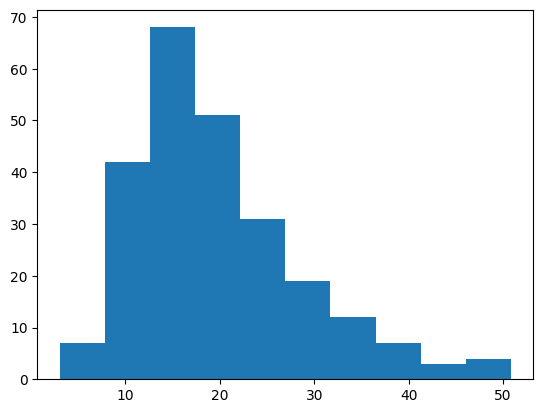

In [52]:
plt.hist(total_bills)

In [57]:
from scipy.stats import skew, kurtosis
# Calculate Mean, Median, and Standard Deviation
mean = np.mean(total_bills)
median = np.median(total_bills)
std_dev = np.std(total_bills)

# Skewness and Kurtosis
data_skewness = skew(total_bills)
data_kurtosis = kurtosis(total_bills, fisher=False)  # Use fisher=False for Pearson's kurtosis

# Empirical Percentages
one_sd = ((sepal_width >= mean - std_dev) & (sepal_width <= mean + std_dev)).sum() / len(sepal_width) * 100
two_sd = ((sepal_width >= mean - 2 * std_dev) & (sepal_width <= mean + 2 * std_dev)).sum() / len(sepal_width) * 100
three_sd = ((sepal_width >= mean - 3 * std_dev) & (sepal_width <= mean + 3 * std_dev)).sum() / len(sepal_width) * 100

# Print Summary
print(f"Mean: {mean:.2f}, Median: {median:.2f}, Std Dev: {std_dev:.2f}")
print(f"Skewness: {data_skewness:.2f} (0 for perfect symmetry)")
print(f"Kurtosis: {data_kurtosis:.2f} (3 for normal distribution)")
print(f"Percentage within 1σ: {one_sd:.2f}% (Expected: 68%)")
print(f"Percentage within 2σ: {two_sd:.2f}% (Expected: 95%)")
print(f"Percentage within 3σ: {three_sd:.2f}% (Expected: 99.7%)")

# Histogram and Normal PDF
x = np.linspace(sepal_width.min(), sepal_width.max(), 1000)
pdf = norm.pdf(x, loc=mean, scale=std_dev)

plt.figure(figsize=(12, 6))
plt.hist(sepal_width, bins=15, density=True, alpha=0.6, color='skyblue', label="Histogram")
plt.plot(x, pdf, label="Fitted Normal PDF", color='red')
plt.title("Sepal Width Distribution and Normal Fit", fontsize=16)
plt.xlabel("Sepal Width (cm)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.axvline(mean, color='blue', linestyle='--', label=f"Mean: {mean:.2f}")
plt.axvline(median, color='green', linestyle='--', label=f"Median: {median:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Standard Deviation Coverage
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label="PDF", color='blue')
plt.axvspan(mean - std_dev, mean + std_dev, color='yellow', alpha=0.3, label="1σ (68%)")
plt.axvspan(mean - 2 * std_dev, mean + 2 * std_dev, color='orange', alpha=0.3, label="2σ (95%)")
plt.axvspan(mean - 3 * std_dev, mean + 3 * std_dev, color='pink', alpha=0.3, label="3σ (99.7%)")
plt.title("Standard Deviations Coverage in Sepal Width", fontsize=16)
plt.xlabel("Sepal Width (cm)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NameError: name 'sepal_width' is not defined

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
19.78594262295082 8.902411954856856


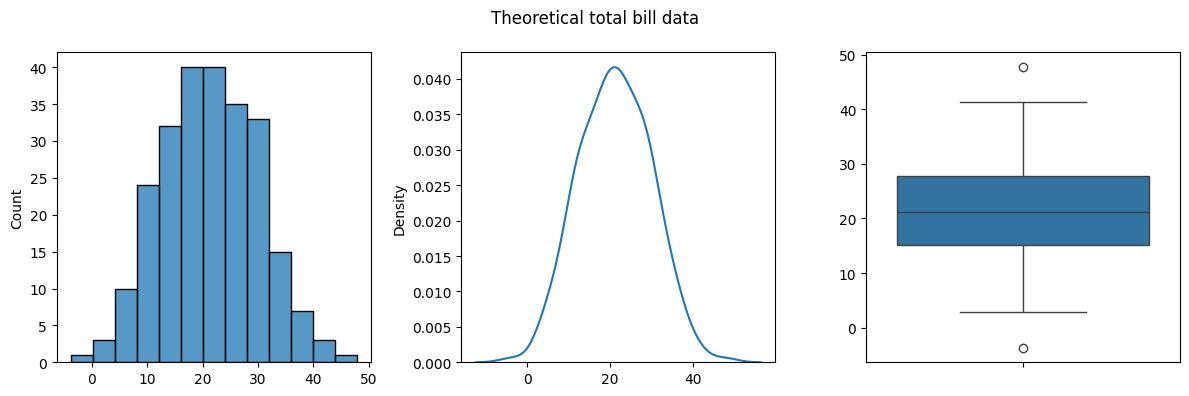

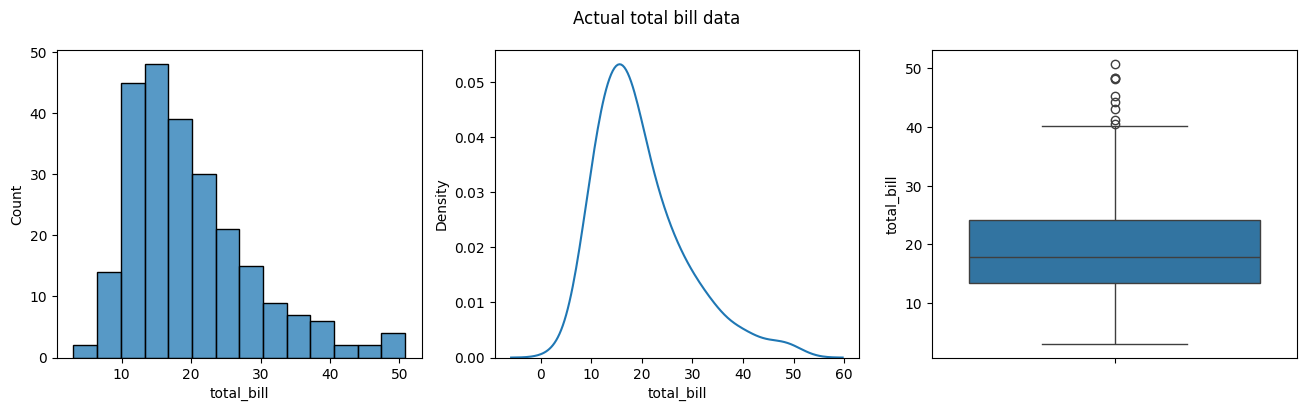

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot
print(tips.head())

# Mean and Std Dev of 'total_bill'
print(tips['total_bill'].mean(), tips['total_bill'].std())

# Generate a theoretical normal distribution based on mean and std dev of 'total_bill'
total_bill_th = norm.rvs(loc=tips['total_bill'].mean(), scale=tips['total_bill'].std(), size=len(tips))

# Plot Histograms, KDEs, and Boxplots for Theoretical and Actual Data
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
plt.suptitle('Theoretical total bill data')
sns.histplot(total_bill_th, ax=ax[0])
sns.kdeplot(total_bill_th, ax=ax[1])
sns.boxplot(total_bill_th, ax=ax[2])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle('Actual total bill data')
sns.histplot(data=tips, x='total_bill', ax=ax[0])
sns.kdeplot(data=tips, x='total_bill', ax=ax[1])
sns.boxplot(data=tips, y='total_bill', ax=ax[2])
plt.show()

Population Mean: 19.79
Population Standard Deviation: 8.88
Sampling Distribution Mean: 19.73
Sampling Distribution Standard Deviation (Standard Error): 1.54


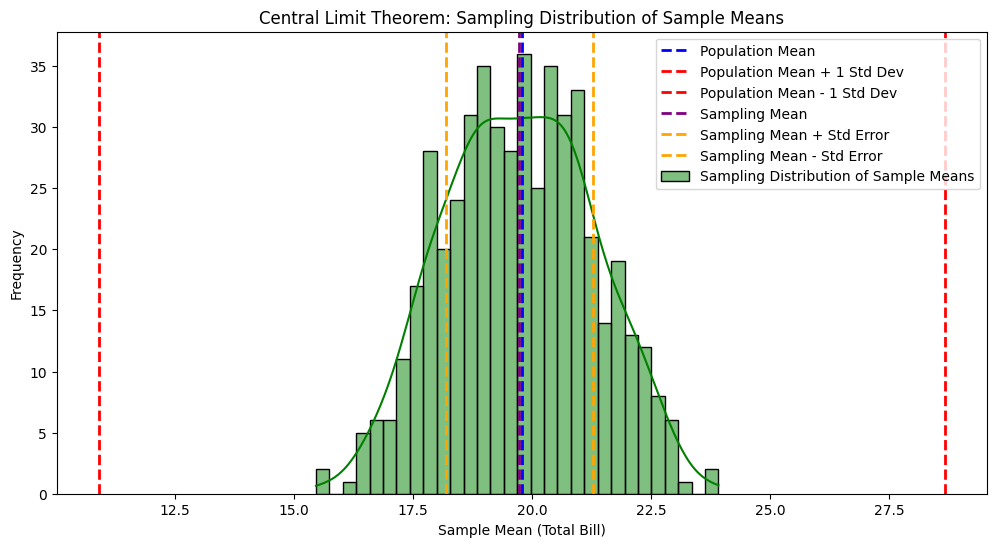

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the 'total_bill' column and treat it as the population
population = tips['total_bill']

# Calculate population mean and standard deviation
population_mean = np.mean(population)
population_std = np.std(population)

print(f"Population Mean: {population_mean:.2f}")
print(f"Population Standard Deviation: {population_std:.2f}")

# Step 1: Draw random samples and compute sample means
sample_size = 30  # Size of each sample
num_samples = 500  # Number of samples to draw
sample_means = []  # To store sample means

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)  # Random sampling
    sample_means.append(np.mean(sample))

# Step 2: Calculate sampling distribution metrics
sampling_mean = np.mean(sample_means)  # Mean of the sampling distribution
sampling_std = np.std(sample_means)    # Standard deviation of the sampling distribution

print(f"Sampling Distribution Mean: {sampling_mean:.2f}")
print(f"Sampling Distribution Standard Deviation (Standard Error): {sampling_std:.2f}")

# Step 3: Visualize the sampling distribution
plt.figure(figsize=(12, 6))
sns.histplot(sample_means, kde=True, color='green', bins=30, label='Sampling Distribution of Sample Means')

# Add vertical lines for population mean and standard deviation
plt.axvline(population_mean, color='blue', linestyle='--', linewidth=2, label='Population Mean')
plt.axvline(population_mean + population_std, color='red', linestyle='--', linewidth=2, label='Population Mean + 1 Std Dev')
plt.axvline(population_mean - population_std, color='red', linestyle='--', linewidth=2, label='Population Mean - 1 Std Dev')

# Add vertical lines for sampling mean and standard error
plt.axvline(sampling_mean, color='purple', linestyle='--', linewidth=2, label='Sampling Mean')
plt.axvline(sampling_mean + sampling_std, color='orange', linestyle='--', linewidth=2, label='Sampling Mean + Std Error')
plt.axvline(sampling_mean - sampling_std, color='orange', linestyle='--', linewidth=2, label='Sampling Mean - Std Error')

# Add labels and title
plt.title('Central Limit Theorem: Sampling Distribution of Sample Means')
plt.xlabel('Sample Mean (Total Bill)')
plt.ylabel('Frequency')
plt.legend()
plt.show()